# Laboratorio 7 - Deep Learning

- Juan Diego Solís Martínez - 23720
- José Gerardo Ruiz García - 23719
- Gerardo André Fernández Cruz - 23763

## Task 3

### Task 3.1

Se generan con NetworkX una red aleatoria (Erdős-Rényi), una libre de escala (Barabási-Albert) y una de mundo pequeño (Watts-Strogatz), todas con $N = 500$. Para cada una se calcula $\langle k \rangle$, $\langle k^2 \rangle$, $\langle C \rangle$, $\langle d \rangle$ y el umbral epidémico crítico $(\beta/\gamma)_c = \langle k \rangle / (\langle k^2 \rangle - \langle k \rangle)$, y se grafica la distribución de grado $P(k)$ de las tres redes.

,<k>,<k^2>,<C>,<d>,(beta/gamma)_c
Red,,,,,
Aleatoria (ER),9.748,104.216,0.0161,2.9674,0.1032
Libre de escala (BA),9.900,203.112,0.0790,2.7308,0.0512
Mundo pequeño (WS),6.000,36.488,0.4645,5.6972,0.1968


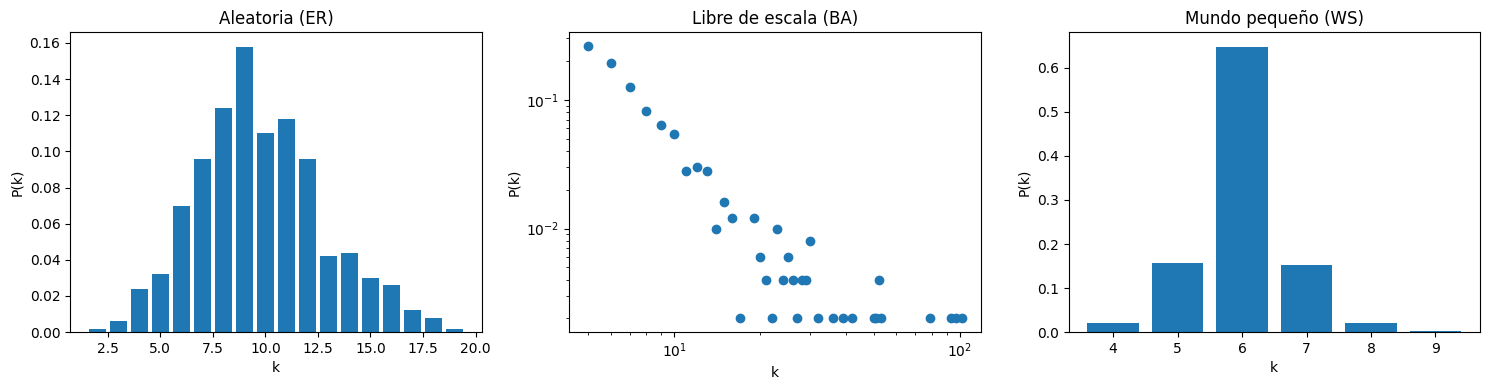

In [ ]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

SEED =42
N= 500

# Generación de las tres redes
redes= {
    "Aleatoria (ER)": nx.erdos_renyi_graph(N, 0.02, seed=SEED),
    "Libre de escala (BA)": nx.barabasi_albert_graph(N, 5, seed=SEED),
    "Mundo pequeño (WS)": nx.watts_strogatz_graph(N, 6, 0.1, seed=SEED),
}

# Métricas: <k>, <k^2>, <C>, <d> y umbral (beta/gamma)_c = <k> / (<k^2> - <k>)
filas=[]
for nombre, G in redes.items():
    k = np.array( [ d for _, d in G.degree()] )
    k1, k2 = k.mean(), (k**2).mean()
    Gc =G.subgraph(max(nx.connected_components(G), key=len) )
    filas.append({
        "Red": nombre,
        "<k>": k1,
        "<k^2>": k2,
        "<C>": nx.average_clustering(G),
        "<d>": nx.average_shortest_path_length(Gc),
        "(beta/gamma)_c": k1 / (k2 - k1),
    })

tabla =pd.DataFrame(filas).set_index("Red").round(4)
display( tabla)

# Distribución de grado P(k) en tres paneles (BA en log-log)
fig, axes = plt.subplots( 1, 3,figsize=( 15, 4 ) )
for ax, (nombre, G) in zip(axes, redes.items() ):
    conteo = Counter(d for _, d in G.degree() )
    ks =sorted(conteo)
    pk= [conteo[x] / N for x in ks]
    
    if "BA" in nombre:
        ax.loglog(ks, pk, "o")
    else:
        ax.bar(ks, pk)
    
    ax.set_title( nombre )
    ax.set_xlabel("k")
    ax.set_ylabel("P(k)")

plt.tight_layout()
plt.savefig("task3_1_distribucion_grado.png", dpi=150)
plt.show()


### Task 3.2

Se simula un proceso SIR en tiempo discreto sobre las tres redes del Task 3.1 con $\beta = 0.04$ por arista por paso y $\gamma = 0.03$ por paso, iniciando con 5 nodos infectados al azar. En cada paso, un susceptible con $n$ vecinos infectados se infecta con probabilidad $1-(1-\beta)^n$ y cada infectado se recupera con probabilidad $\gamma$. Se corren 50 realizaciones por red, se reporta la media y el IC del 95% del tamaño final del brote, se grafican las trayectorias de $I(t)/N$ con su media y se imprimen los datos para comparar las topologías.

,Media,IC 95% inf,IC 95% sup,Desv. est.,Mín,Máx
Red,,,,,,
Aleatoria (ER),0.9968,0.9962,0.9973,0.0019,0.992,1.0
Libre de escala (BA),0.9954,0.9945,0.9963,0.0033,0.986,1.0
Mundo pequeño (WS),0.9841,0.9807,0.9875,0.0123,0.940,1.0


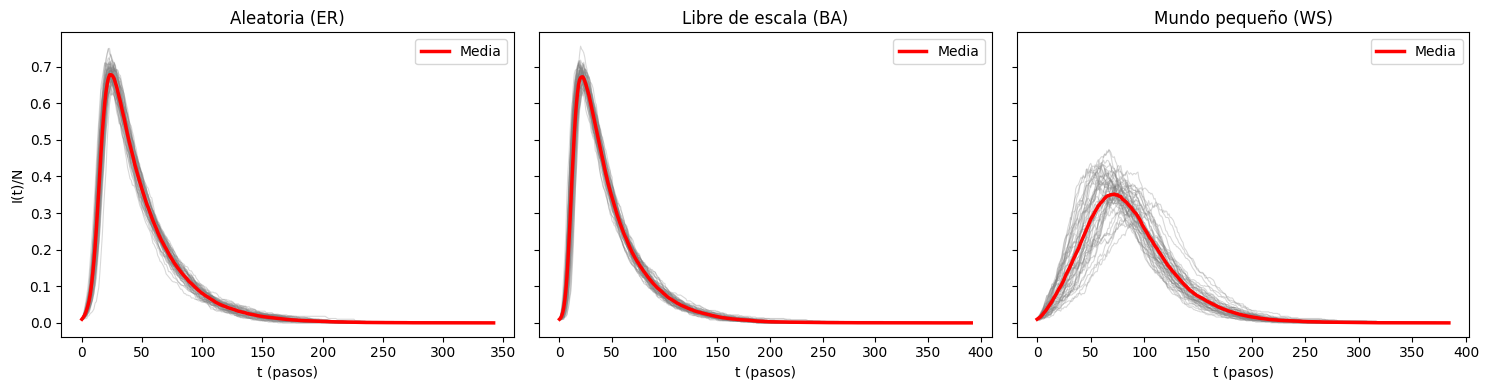

Aleatoria (ER): pico medio I/N = 0.693, t pico medio = 23.6, beta/gamma = 1.333 vs umbral = 0.1032
Libre de escala (BA): pico medio I/N = 0.687, t pico medio = 20.7, beta/gamma = 1.333 vs umbral = 0.0512
Mundo pequeño (WS): pico medio I/N = 0.389, t pico medio = 70.9, beta/gamma = 1.333 vs umbral = 0.1968


In [ ]:
BETA, GAMMA=0.04, 0.03
N_REAL, I0= 50, 5
rng =np.random.default_rng(SEED)

def sir(G):
    A= nx.to_numpy_array(G)
    estado =np.zeros(N, dtype=int) # 0 = S, 1 = I, 2 = R
    estado[ rng.choice(N, I0, replace=False) ] = 1
    I_t=[I0 / N ]

    while(estado == 1).any():
        n_inf = A @ (estado==1) # vecinos infectados de cada nodo
        nuevos_I = (estado ==0) & (rng.random(N) < 1 - (1 - BETA) ** n_inf)
        nuevos_R = (estado== 1) & (rng.random(N) < GAMMA)
        estado[nuevos_I], estado[nuevos_R] = 1, 2
        I_t.append((estado ==1).sum() / N )

    return (estado == 2 ).sum() / N, np.array( I_t) # tamaño final = fracción de recuperados

resultados={nombre: [sir(G) for _ in range(N_REAL)] for nombre, G in redes.items()}

# a. Media e IC del 95% del tamaño final del brote
filas =[]

for nombre, res in resultados.items():
    tam = np.array( [r[0] for r in res ] )
    media, err = tam.mean(), 1.96 * tam.std(ddof=1) / np.sqrt(N_REAL)
    filas.append({"Red": nombre, "Media": media, "IC 95% inf": media - err, "IC 95% sup": media + err,
                  "Desv. est.": tam.std(ddof=1), "Mín": tam.min(), "Máx": tam.max()})
    
tabla_sir = pd.DataFrame(filas).set_index("Red").round(4)
display(tabla_sir)

# b. Trayectorias de I(t)/N con la media en línea gruesa
fig, axes = plt.subplots(1, 3, figsize=( 15, 4), sharey=True)

for ax, (nombre, res ) in zip(axes, resultados.items() ):
    T = max(len(r[1] ) for r in res)
    trayectorias = np.array( [np.pad(r[1], (0, T - len(r[1]) )) for r in res] )  # se rellena con 0 al terminar el brote
    for tr in trayectorias:
        ax.plot(tr, color="gray", alpha=0.3, lw=0.8)
    
    ax.plot(trayectorias.mean(axis=0), color="red", lw=2.5, label="Media")
    ax.set_title(nombre)
    ax.set_xlabel("t (pasos)")
    ax.legend()
    
axes[0].set_ylabel("I(t)/N")
plt.tight_layout()
plt.savefig("task3_2_trayectorias.png", dpi=150)
plt.show()

# c. Datos para comparar: pico de I(t)/N, tiempo al pico y comparación con el umbral
for nombre, res in resultados.items():
    picos =[r[1].max() for r in res]
    t_pico= [r[1].argmax() for r in res]
    print(f"{nombre}: pico medio I/N = {np.mean(picos):.3f}, t pico medio = {np.mean(t_pico):.1f}, "
          f"beta/gamma = {BETA/GAMMA:.3f} vs umbral = {tabla.loc[nombre, '(beta/gamma)_c']:.4f}")
